# Training MLP Pressure Controller 3-4-1 — Data Closed-Loop 14 Juni 2026

Notebook ini melatih **jaringan saraf tiruan kecil** untuk mengatur tekanan pompa.
Selain kode, notebook ini diberi **penjelasan fundamental** supaya bisa dipakai belajar.

**Rancangan singkat:**
- Input (3): `[error, Δerror, duty_t]`
- Output (1): `ΔDuty` (perubahan duty, BUKAN duty absolut)
- Arsitektur: **MLP 3-4-1** (tanh di hidden, linear di output)
- Saat dipakai: `duty_berikutnya = batasi(duty_sekarang + ΔDuty_prediksi, 70, 95)`

---
# BAGIAN 0, FUNDAMENTAL

## 0.1 Jenis jaringan saraf 

"Neural network" itu payung besar. Pohon keluarganya:

```
ANN (Artificial Neural Network)  ── payung semua jaringan saraf tiruan
 │
 ├── MLP / Feedforward (fully-connected)  ◀── INI YANG KITA PAKAI
 │      data mengalir maju 1 arah, tiap neuron terhubung ke semua neuron berikutnya
 │
 ├── CNN (Convolutional)   → untuk GAMBAR (pakai konvolusi/filter). BUKAN ini.
 │
 └── RNN / LSTM            → untuk DERET WAKTU (punya "memori"/loop). BUKAN ini.
```

**Model kita = ANN jenis MLP (Multilayer Perceptron)**, yaitu jaringan **feedforward
fully-connected**. Kadang disebut "vanilla neural network".

- **Bukan CNN** — CNN untuk citra (mendeteksi pola spasial dengan filter). Data kita bukan gambar.
- **Bukan RNN** — RNN punya memori antar-waktu. Kita TIDAK pakai memori internal; sebagai
  gantinya kita masukkan `Δerror` (perubahan error) sebagai fitur, jadi informasi "tren waktu"
  tetap masuk tanpa perlu RNN. Inilah cara murah menangkap dinamika di MLP.

Jadi jawabannya: **ANN → MLP (feedforward) — BUKAN CNN.**

## 0.2 Bagian-bagian sebuah MLP

```
        INPUT (3)            HIDDEN (4)            OUTPUT (1)
       error  ●───┐        ┌─► ● tanh ─┐
     d_error  ●───┼──────► ├─► ● tanh ─┼──────►  ● (linear)  →  ΔDuty
        duty  ●───┘        ├─► ● tanh ─┤
                           └─► ● tanh ─┘
            (tiap garis = 1 bobot/weight; tiap neuron punya 1 bias)
```

- **Neuron** = satu unit hitung kecil.
- **Bobot (weight, W)** = angka pada tiap koneksi → seberapa besar pengaruh satu input ke neuron.
- **Bias (b)** = angka tambahan per neuron → menggeser hasil (seperti konstanta di `y = wx + b`).
- **Fungsi aktivasi** = fungsi non-linear pada neuron hidden. Kita pakai **tanh** (keluaran −1..+1).
  Tanpa aktivasi non-linear, seluruh jaringan cuma jadi **regresi linear biasa** — tak bisa
  belajar pola melengkung. Aktivasi inilah yang memberi NN "kekuatan".

**Arsitektur 3-4-1** artinya: **3** neuron input, **4** neuron hidden, **1** neuron output.
Jumlah parameter (yang dipelajari):
- Layer 1: 3×4 bobot + 4 bias = 16
- Layer 2: 4×1 bobot + 1 bias = 5
- **Total = 21 parameter.** Sangat kecil → muat di STM32 & butuh sedikit data.

## 0.3 Forward pass (cara menghitung output)

Diberi input `x = [error, Δerror, duty]`:
1. **Skala** tiap input: `x' = (x − mean) / std`  (lihat 0.5).
2. **Hidden**: untuk tiap neuron j → `z_j = b1_j + Σ_i (x'_i · W1_ij)` lalu `h_j = tanh(z_j)`.
3. **Output**: `ΔDuty = b2 + Σ_j (h_j · W2_j)`  (linear, tanpa tanh).

Itu saja — perkalian + penjumlahan + tanh. Inferensi NN ini ringan.

## 0.4 Bagaimana NN "belajar"? (training)

- **Loss (rugi)** = ukuran seberapa salah prediksi. Kita pakai **MSE** = rata-rata `(prediksi − target)²`.
- **Optimizer** menyetel ke-21 parameter agar loss sekecil mungkin, lewat **backpropagation**
  (menghitung arah perbaikan tiap bobot). Kita pakai `lbfgs` (cocok untuk data kecil) dan
  `adam` (untuk menggambar kurva loss per-epoch).
- **Epoch** = satu kali jaringan melihat seluruh data latih. Loss turun tiap epoch sampai stabil.

## 0.5 Istilah penting lain

- **Scaling (StandardScaler)**: fitur kita beda skala (`error`≈0.1, `duty`≈80). Tanpa diseragamkan,
  `duty` mendominasi. StandardScaler mengubah tiap fitur ke **mean 0, std 1** → training stabil.
- **Train / Validation / Test**:
  - *Train* (≈70%) → dipakai belajar (menyetel bobot).
  - *Validation* (≈10%) → memantau overfitting / memilih kapan berhenti. Tidak dipakai menyetel bobot.
  - *Test* (≈20%) → data yang **tak pernah dilihat** model → ukuran kejujuran performa.
- **Overfitting**: model "menghafal" data latih tapi buruk di data baru. Tanda: loss train jauh
  lebih kecil dari loss test. Dicegah dengan model kecil + validation.

## 0.6 Apa itu BASELINE & kenapa penting?

**Baseline** = model pembanding yang **sangat sederhana**. Gunanya: membuktikan NN benar-benar
memberi nilai tambah. Kalau NN tak bisa mengalahkan tebakan bodoh, berarti NN tak berguna.

Baseline yang kita pakai:
- **ΔDuty = 0** → "tidak melakukan apa-apa" (controller diam). Kalau NN kalah dari ini, NN gagal.
- **Proporsional (ΔDuty = k·error)** → kontroler-P linear sederhana. Kalau NN menang dari ini,
  berarti NN menangkap pola **non-linear** yang tak bisa ditangkap garis lurus.

> ⚠️ Pelajaran dari notebook lama: dulu target = `duty.shift(-1)` membuat target ≈ input,
> sehingga baseline "ulangi duty sebelumnya" menyamai NN (R² 0.98 **palsu**). Maka memilih
> baseline yang tepat itu krusial untuk tahu apakah model sungguh belajar.

## 0.7 Metrik penilaian

- **MAE** = rata-rata |error| → "rata-rata meleset berapa %". Mudah dibaca.
- **RMSE** = akar rata-rata error² → menghukum kesalahan besar lebih keras.
- **R²** = proporsi variasi yang berhasil dijelaskan model (1 = sempurna, 0 = sebaik menebak
  rata-rata, negatif = lebih buruk dari menebak rata-rata).

---

## 1. Import library
`numpy/pandas` untuk data, `matplotlib` untuk grafik, `sklearn` untuk MLP + alat bantu
(scaler, split, metrik).

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
np.set_printoptions(suppress=True)

## 2. Konfigurasi
Semua "saklar" eksperimen ada di sini supaya gampang diubah.
- `INCLUDE_F1` → ikutkan data setpoint 0.25? (mendukung klaim setpoint adjustable)
- `HIDDEN=(4,)` → jumlah neuron hidden = 4 (inilah "4" pada 3-**4**-1)
- `DUTY_MIN/MAX` → batas duty saat dipakai (samakan dgn saat ambil data)
- `FEATURES/TARGET` → 3 input & 1 output sesuai rancangan

In [2]:
DATA_DIR = r'E:\\SEMESTER 8\\TA\\BUKU TA_YOEL\\DATA TRAINING 14 JUNI'

INCLUDE_F1   = True     # ikutkan data setpoint 0.25 (f1)?
HIDDEN       = (4,)     # MLP 3-4-1
RANDOM_STATE = 42
TEST_SIZE    = 0.20
VAL_FRACTION = 0.125    # dari trainval -> ~10% total
DUTY_MIN     = 70.0
DUTY_MAX     = 95.0

FEATURES = ['error', 'd_error', 'duty_percent']
TARGET   = 'delta_duty'

## 3. Load & gabung semua file

**Kenapa perlu digabung khusus?** Tiap file punya `episode_id` mulai dari 1, jadi banyak file
punya "episode 1". Kalau langsung disatukan, dua episode berbeda dianggap satu → nanti perhitungan
`Δ` (selisih antar-baris) akan menyambung dua episode yang tak berhubungan (transisi palsu).

**Solusi:** tiap pasangan `(file, episode_id)` diberi nomor **`global_episode`** yang unik.
Baris korup (mis. catatan manual "3 keran lupa" di c2) dibuang otomatis.

In [3]:
KEY = ['pressure_bar', 'duty_percent', 'setpoint_bar', 'episode_id', 'is_decision']
files = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
print(f'Ditemukan {len(files)} file CSV')

parts, meta, gid = [], [], 0
for f in files:
    d = pd.read_csv(f)
    for c in KEY:
        d[c] = pd.to_numeric(d[c], errors='coerce')
    d['valve_open_count'] = pd.to_numeric(d['valve_open_count'], errors='coerce')
    d = d.dropna(subset=KEY)                      # buang baris korup/catatan
    for ep in sorted(d['episode_id'].unique()):
        gid += 1
        sub = d[d['episode_id'] == ep].copy()
        sub['global_episode'] = gid
        sub['src'] = os.path.basename(f)
        parts.append(sub)
        meta.append({'file': os.path.basename(f), 'ep_lokal': int(ep),
                     'global_episode': gid,
                     'baris_keputusan': int((sub['is_decision'] == 1).sum()),
                     'valve': sorted(sub['valve_open_count'].dropna().unique().tolist()),
                     'setpoint': sorted(sub['setpoint_bar'].unique().tolist())})

df = pd.concat(parts, ignore_index=True)
meta_df = pd.DataFrame(meta)
print(f'Total episode global: {gid} | total baris: {len(df)}')
meta_df

Ditemukan 12 file CSV
Total episode global: 16 | total baris: 4035


,file,ep_lokal,global_episode,baris_keputusan,valve,setpoint
0,14junia1a2.csv,1,1,18,[4],[0.3]
1,14junia1a2.csv,2,2,17,[4],[0.3]
2,14junia3a4.csv,1,3,12,[3],[0.3]
3,14junia3a4.csv,2,4,17,[3],[0.3]
4,14junib1b2.csv,1,5,14,[0],[0.3]
5,14junib1b2.csv,2,6,9,[1],[0.3]
6,14junib3b4.csv,1,7,11,[2],[0.3]
7,14junib3b4.csv,2,8,7,[3],[0.3]
8,14junic1.csv,1,9,45,"[0, 1, 2, 3, 4]",[0.3]
9,14junic2.csv,1,10,38,"[0.0, 1.0, 2.0, 4.0]",[0.3]


## 4. Feature engineering — membuat input & target

Ini inti yang membedakan dari notebook lama. Kita HANYA pakai baris **keputusan**
(`is_decision==1`, yaitu titik tiap 3 detik saat controller mengambil keputusan), lalu:

| Kolom | Rumus | Arti |
|---|---|---|
| `error` | `setpoint − pressure` | seberapa jauh dari target (input 1) |
| `d_error` | `error.diff()` per episode | tren error / "kecepatan" (input 2) |
| `duty_percent` | apa adanya | posisi aktuator sekarang (input 3) |
| `delta_duty` | `duty.diff().shift(-1)` per episode | **aksi koreksi berikutnya = TARGET** |

- `.diff()` & `.shift(-1)` dilakukan **per `global_episode`** supaya tidak menyambung antar-episode.
- Baris **terakhir tiap episode** dibuang (target `delta_duty` kosong di batas episode).
- `delta_duty` = perubahan duty yang BENAR-BENAR dilakukan manusia di keputusan itu → model
  belajar **meniru keputusan** (ini disebut *behavior cloning*).

In [4]:
dec = df[df['is_decision'] == 1].copy().reset_index(drop=True)

dec['error']      = dec['setpoint_bar'] - dec['pressure_bar']
dec['d_error']    = dec.groupby('global_episode')['error'].diff().fillna(0.0)
dec['delta_duty'] = dec.groupby('global_episode')['duty_percent'].diff().shift(-1)

data = dec.dropna(subset=['delta_duty']).reset_index(drop=True)
if not INCLUDE_F1:
    data = data[np.isclose(data['setpoint_bar'], 0.30)].reset_index(drop=True)

print(f'Baris keputusan : {len(dec)}')
print(f'Baris siap latih: {len(data)}  (INCLUDE_F1={INCLUDE_F1})')

Baris keputusan : 469
Baris siap latih: 453  (INCLUDE_F1=True)


### 4b. Ringkasan dataset
Kita cek: sebaran target (naik/turun/tahan harus seimbang), rentang tiap fitur, dan jumlah per setpoint.
Sebaran target yang beragam = tanda data tidak trivial.

In [5]:
print('=== Distribusi target ΔDuty ===')
print('  naik (>0) :', int((data[TARGET] > 0).sum()))
print('  turun (<0):', int((data[TARGET] < 0).sum()))
print('  tahan (=0):', int((data[TARGET] == 0).sum()))
print('  nilai unik:', sorted(data[TARGET].unique().tolist()))
print()
print('=== Rentang fitur ===')
print(data[FEATURES].describe().loc[['min', 'mean', 'max']].T)
print()
print('=== Baris per setpoint ===')
print(data.groupby('setpoint_bar').size())

=== Distribusi target ΔDuty ===
  naik (>0) : 161
  turun (<0): 91
  tahan (=0): 201
  nilai unik: [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]

=== Rentang fitur ===
                    min       mean        max
error         -0.508800  -0.014887   0.230533
d_error       -0.397733  -0.001208   0.557933
duty_percent  65.000000  82.282561  95.000000

=== Baris per setpoint ===
setpoint_bar
0.25     50
0.30    403
dtype: int64


### 4c. Visual
Kiri: histogram target (lihat apakah seimbang). Kanan: hubungan `error` vs `ΔDuty`.
**Korelasi sedang-kuat tapi BUKAN 1.0** = bagus: error prediktif terhadap aksi, tetapi
hubungannya non-linear (itulah tugas NN). Kalau korelasi = 1.0, berarti trivial.

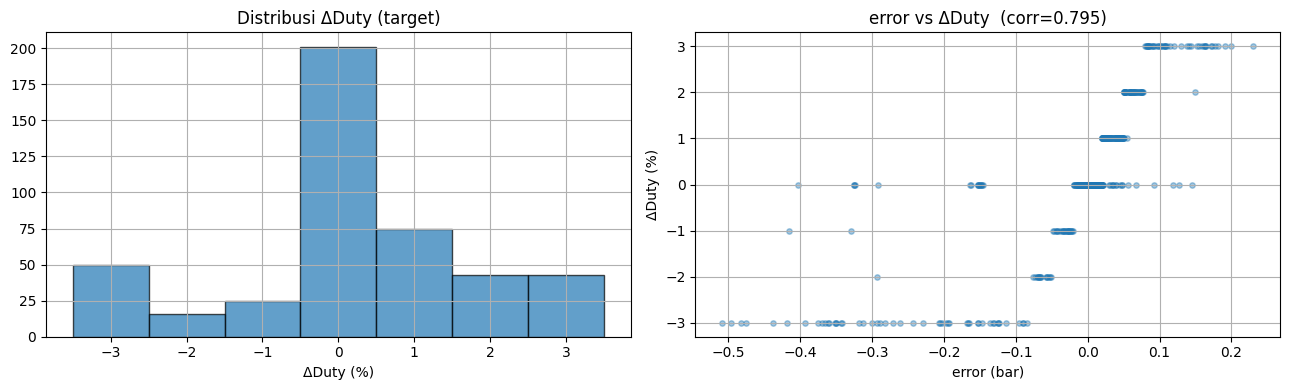

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(data[TARGET], bins=np.arange(-3.5, 4.5, 1.0), edgecolor='k', alpha=0.7)
ax[0].set_title('Distribusi ΔDuty (target)'); ax[0].set_xlabel('ΔDuty (%)')
ax[1].scatter(data['error'], data[TARGET], alpha=0.4, s=15)
ax[1].set_title(f"error vs ΔDuty  (corr={data['error'].corr(data[TARGET]):.3f})")
ax[1].set_xlabel('error (bar)'); ax[1].set_ylabel('ΔDuty (%)')
plt.tight_layout(); plt.show()

## 5. Bagi data Train / Validation / Test (70:10:20)

- **Train** → model belajar dari sini.
- **Validation** → memantau apakah mulai overfitting (tidak menyetel bobot).
- **Test** → "ujian" di data yang tak pernah dilihat → angka performa yang jujur.

`X` = matriks fitur (3 kolom), `y` = vektor target (ΔDuty). `shuffle=True` mengacak baris.

In [7]:
X = data[FEATURES].to_numpy(np.float32)
y = data[TARGET].to_numpy(np.float32)

idx = np.arange(len(data))
trainval_idx, test_idx = train_test_split(idx, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True)
train_idx, val_idx = train_test_split(trainval_idx, test_size=VAL_FRACTION, random_state=RANDOM_STATE, shuffle=True)

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]
print(f'Train {len(train_idx)} | Val {len(val_idx)} | Test {len(test_idx)}')

Train 316 | Val 46 | Test 91


## 6. Training MLP 3-4-1

`Pipeline` menyatukan 2 langkah agar selalu berurutan: **(1) StandardScaler** (seragamkan skala
fitur) → **(2) MLPRegressor** (jaringannya).

Parameter penting MLPRegressor:
- `hidden_layer_sizes=(4,)` → 1 lapisan hidden berisi 4 neuron (arsitektur 3-**4**-1).
- `activation='tanh'` → fungsi aktivasi non-linear di hidden.
- `solver='lbfgs'` → optimizer yang bagus untuk dataset kecil.
- `alpha=1e-3` → regularisasi (menghukum bobot besar → mencegah overfitting).

Fungsi `metrics()` menghitung RMSE/MAE/R² sekaligus.

In [8]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=HIDDEN,
        activation='tanh',
        solver='lbfgs',
        alpha=1e-3,
        max_iter=5000,
        random_state=RANDOM_STATE,
        tol=1e-7,
    )),
])
model.fit(X_train, y_train)

def metrics(yt, yp):
    return {'RMSE': np.sqrt(mean_squared_error(yt, yp)),
            'MAE': mean_absolute_error(yt, yp),
            'R2': r2_score(yt, yp)}

pred_tr, pred_va, pred_te = model.predict(X_train), model.predict(X_val), model.predict(X_test)
print('=== MLP 3-4-1 ===')
print('Train:', {k: round(v, 4) for k, v in metrics(y_train, pred_tr).items()})
print('Val  :', {k: round(v, 4) for k, v in metrics(y_val,   pred_va).items()})
print('Test :', {k: round(v, 4) for k, v in metrics(y_test,  pred_te).items()})
print()
print('Catatan: gap Train vs Test kecil = tidak overfit.')

=== MLP 3-4-1 ===
Train: {'RMSE': 0.4171, 'MAE': 0.311, 'R2': 0.9324}
Val  : {'RMSE': 0.5409, 'MAE': 0.3341, 'R2': 0.8817}
Test : {'RMSE': 0.4629, 'MAE': 0.3287, 'R2': 0.9152}

Catatan: gap Train vs Test kecil = tidak overfit.


## 7. Perbandingan dengan BASELINE (inti pembuktian)

Lihat penjelasan baseline di Bagian 0.6. Di sini kita uji NN melawan:
- **ΔDuty=0** (diam) — NN WAJIB mengalahkan ini.
- **P (k·error)** — kontroler proporsional linear; `k` dicari otomatis (least squares) dari data train.

Kalau NN menang dari keduanya → NN benar-benar belajar kontrol non-linear, bukan trivial.

In [9]:
# baseline delta=0
b0 = np.zeros_like(y_test)
# baseline proporsional: cari k via least squares di train
k = np.sum(X_train[:, 0] * y_train) / np.sum(X_train[:, 0] ** 2)
bp = k * X_test[:, 0]
print(f'Gain proporsional ter-fit: k = {k:.2f} (ΔDuty = {k:.1f} * error)')
print()
rows = [
    {'Model': 'MLP 3-4-1',        **metrics(y_test, pred_te)},
    {'Model': 'Baseline ΔDuty=0', **metrics(y_test, b0)},
    {'Model': 'Baseline P (k*err)', **metrics(y_test, bp)},
]
print(pd.DataFrame(rows).round(4).to_string(index=False))

Gain proporsional ter-fit: k = 10.49 (ΔDuty = 10.5 * error)

             Model   RMSE    MAE      R2
         MLP 3-4-1 0.4629 0.3287  0.9152
  Baseline ΔDuty=0 1.5967 1.1209 -0.0094
Baseline P (k*err) 0.9996 0.7402  0.6044


## 8. Kurva Loss (melihat proses belajar)

`lbfgs` tidak menyimpan loss per-epoch, jadi di sini kita latih ulang model yang sama
dengan `adam` + `partial_fit` (belajar bertahap) hanya untuk **menggambar kurva loss**.

- **Train loss turun** = model makin pintar di data latih.
- **Val loss** = patokan generalisasi. Saat val loss berhenti turun lalu naik → mulai overfit;
  kita catat **best epoch** (titik val loss terendah) — itu model terbaik.

Stop di epoch 509 | best val MSE 0.1543 @ epoch 259


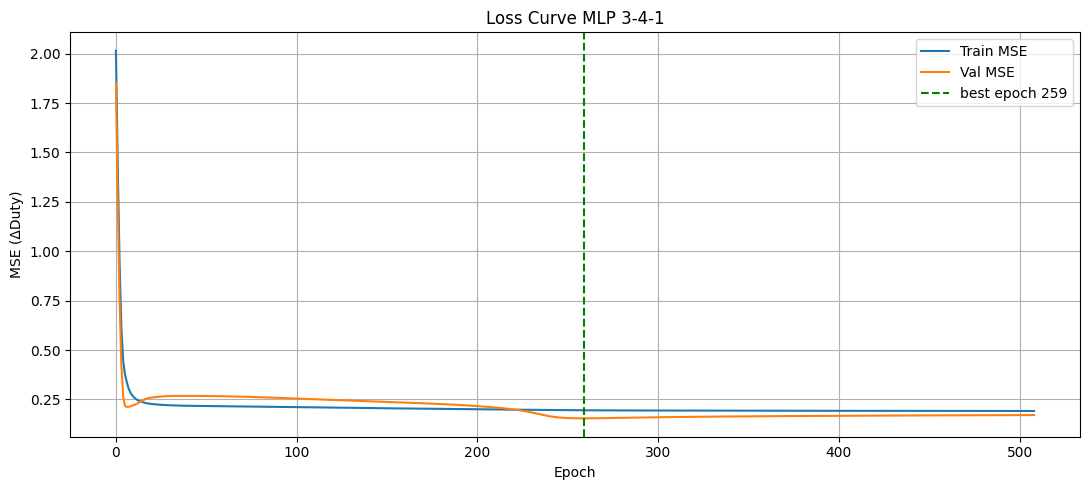

In [10]:
scaler = StandardScaler().fit(X_train)
Xtr, Xva = scaler.transform(X_train), scaler.transform(X_val)

mlp = MLPRegressor(hidden_layer_sizes=HIDDEN, activation='tanh', solver='adam',
                   alpha=1e-3, learning_rate_init=0.02, max_iter=1,
                   warm_start=True, random_state=RANDOM_STATE,
                   batch_size=min(32, len(Xtr)), tol=1e-9, n_iter_no_change=10**9)

tr_hist, va_hist, best, best_ep, patience, bad = [], [], np.inf, 0, 250, 0
for ep in range(1, 3001):
    mlp.partial_fit(Xtr, y_train)
    tl = mean_squared_error(y_train, mlp.predict(Xtr))
    vl = mean_squared_error(y_val,   mlp.predict(Xva))
    tr_hist.append(tl); va_hist.append(vl)
    if vl < best - 1e-7:
        best, best_ep, bad = vl, ep, 0
    else:
        bad += 1
        if bad >= patience:
            break
print(f'Stop di epoch {len(tr_hist)} | best val MSE {best:.4f} @ epoch {best_ep}')

plt.figure(figsize=(11, 5))
plt.plot(tr_hist, label='Train MSE')
plt.plot(va_hist, label='Val MSE')
plt.axvline(best_ep, color='g', ls='--', label=f'best epoch {best_ep}')
plt.xlabel('Epoch'); plt.ylabel('MSE (ΔDuty)'); plt.title('Loss Curve MLP 3-4-1')
plt.legend(); plt.tight_layout(); plt.show()

## 9. Visualisasi prediksi

- **Kiri (scatter):** target vs prediksi. Makin dekat ke garis `y=x` (merah) makin akurat.
- **Kanan (deret):** membandingkan ΔDuty target vs prediksi titik-per-titik di data test.

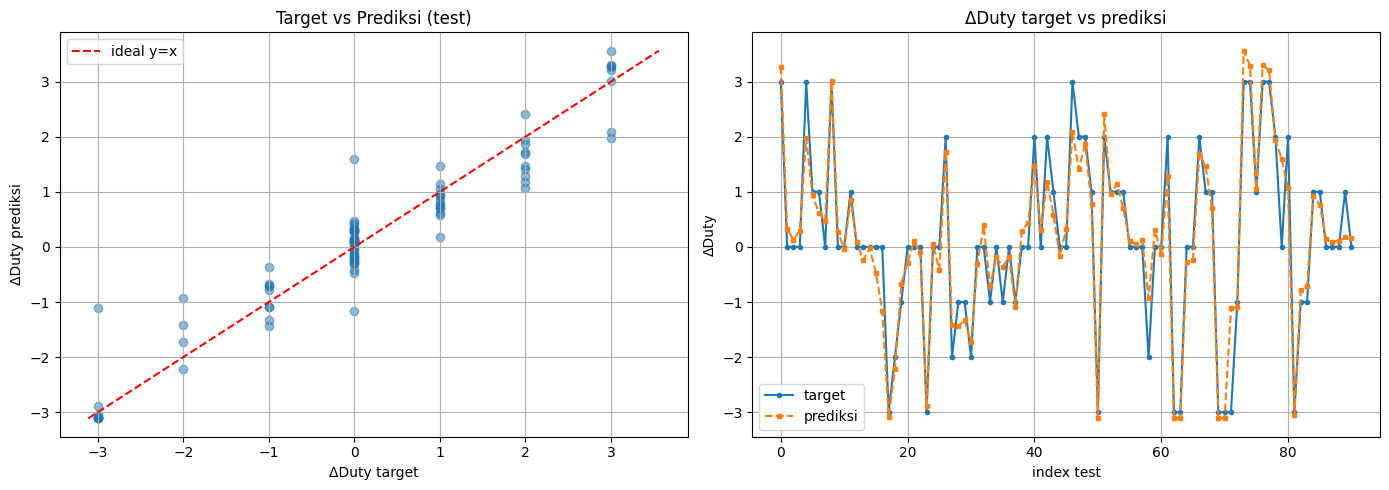

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(y_test, pred_te, alpha=0.5)
lo, hi = min(y_test.min(), pred_te.min()), max(y_test.max(), pred_te.max())
ax[0].plot([lo, hi], [lo, hi], 'r--', label='ideal y=x')
ax[0].set_xlabel('ΔDuty target'); ax[0].set_ylabel('ΔDuty prediksi')
ax[0].set_title('Target vs Prediksi (test)'); ax[0].legend()

order = np.argsort(test_idx)
ax[1].plot(y_test[order], 'o-', ms=3, label='target')
ax[1].plot(pred_te[order], 's--', ms=3, label='prediksi')
ax[1].set_xlabel('index test'); ax[1].set_ylabel('ΔDuty'); ax[1].legend()
ax[1].set_title('ΔDuty target vs prediksi')
plt.tight_layout(); plt.show()

## 10. Simulasi closed-loop (uji 1 episode penuh)

Uji model sebagai controller sungguhan pada satu episode: mulai dari duty awal episode, lalu
tiap langkah `duty_baru = batasi(duty + ΔDuty_prediksi, 70, 95)`, memakai tekanan AKTUAL yang
terekam sebagai gangguan. Kalau garis **duty simulasi (merah)** mengikuti **duty manusia (hitam)**,
berarti model meniru kebijakan kontrol dengan baik.

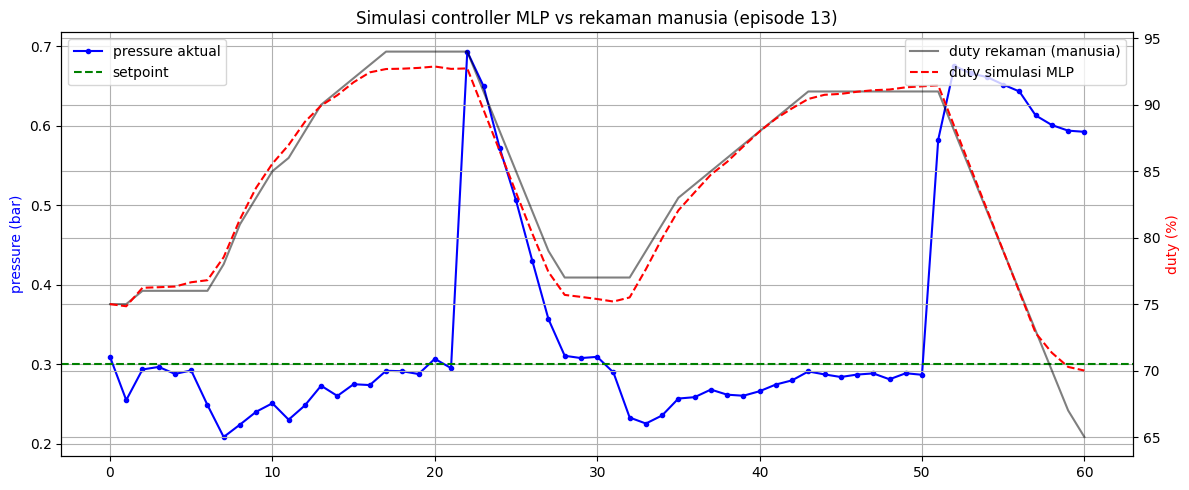

In [12]:
ep_pick = data.groupby('global_episode').size().idxmax()
epd = data[data['global_episode'] == ep_pick].reset_index(drop=True)

duty_sim = [epd['duty_percent'].iloc[0]]
for i in range(len(epd)):
    err = epd['setpoint_bar'].iloc[i] - epd['pressure_bar'].iloc[i]
    derr = epd['d_error'].iloc[i]
    x = np.array([[err, derr, duty_sim[-1]]], np.float32)
    dd = float(model.predict(x)[0])
    duty_sim.append(float(np.clip(duty_sim[-1] + dd, DUTY_MIN, DUTY_MAX)))
duty_sim = duty_sim[:-1]

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(epd['pressure_bar'].values, 'b-o', ms=3, label='pressure aktual')
ax1.axhline(epd['setpoint_bar'].iloc[0], color='g', ls='--', label='setpoint')
ax1.set_ylabel('pressure (bar)', color='b'); ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(epd['duty_percent'].values, 'k-', alpha=0.5, label='duty rekaman (manusia)')
ax2.plot(duty_sim, 'r--', label='duty simulasi MLP')
ax2.set_ylabel('duty (%)', color='r'); ax2.legend(loc='upper right')
plt.title(f'Simulasi controller MLP vs rekaman manusia (episode {ep_pick})')
plt.tight_layout(); plt.show()

## 11. Export bobot untuk STM32 (3 input)

Mengeluarkan ke-21 parameter (mean/scale scaler, W1, B1, W2, B2) sebagai array C siap salin.

> ⚠️ Firmware sekarang `MLP_Forward` memakai **5 input**. Untuk model baru ini, firmware perlu
> diganti ke versi **3 input** `[error, d_error, duty]` dengan output ΔDuty, lalu
> `duty = clamp(duty + ΔDuty, 70, 95)`. Kode forward C disertakan di bawah.

In [13]:
scaler_f = model.named_steps['scaler']
mlp_f    = model.named_steps['mlp']
mean_, scale_ = scaler_f.mean_, scaler_f.scale_
W1, b1 = mlp_f.coefs_[0], mlp_f.intercepts_[0]   # (3,4), (4,)
W2, b2 = mlp_f.coefs_[1], mlp_f.intercepts_[1]   # (4,1), (1,)

def carr(a, name, fmt='%.8ff'):
    a = np.atleast_2d(a)
    if a.shape[0] == 1:
        body = ', '.join(fmt % v for v in a.ravel())
        return f'static const float {name}[{a.shape[1]}] = {{ {body} }};'
    rows = ',\n    '.join('{ ' + ', '.join(fmt % v for v in r) + ' }' for r in a)
    return f'static const float {name}[{a.shape[0]}][{a.shape[1]}] = {{\n    {rows}\n}};'

print('/* === MLP 3-4-1 (input: error, d_error, duty) === */')
print(carr(mean_,  'scaler_mean'))
print(carr(scale_, 'scaler_scale'))
print(carr(W1, 'W1'))
print(carr(b1, 'B1'))
print(carr(W2.T, 'W2'))
print(carr(b2, 'B2'))
print('''
/* Forward (C):
float in[3] = { error, d_error, duty };
for (i=0;i<3;i++) in[i] = (in[i]-scaler_mean[i])/scaler_scale[i];
for (j=0;j<4;j++){ float s=B1[j]; for(i=0;i<3;i++) s+=in[i]*W1[i][j]; h[j]=tanhf(s); }
float dd=B2[0]; for(j=0;j<4;j++) dd+=h[j]*W2[j];
duty = clampf(duty + dd, 70.0f, 95.0f);
*/''')

/* === MLP 3-4-1 (input: error, d_error, duty) === */
static const float scaler_mean[3] = { -0.01586624f, 0.00100443f, 82.27215190f };
static const float scaler_scale[3] = { 0.11593238f, 0.06163191f, 7.13180498f };
static const float W1[3][4] = {
    { -1.15757672f, 1.71712945f, -3.65813410f, -16.90999678f },
    { 0.00773297f, 0.17402844f, -3.60776505f, 7.44927295f },
    { 0.92057488f, 0.77042528f, -11.97423637f, 10.49031145f }
};
static const float B1[4] = { 0.50083114f, -0.39519265f, -22.83592021f, -7.20119188f };
static const float W2[4] = { -1.36458051f, 1.70422781f, 0.99562945f, -0.30379082f };
static const float B2[1] = { 1.25671514f };

/* Forward (C):
float in[3] = { error, d_error, duty };
for (i=0;i<3;i++) in[i] = (in[i]-scaler_mean[i])/scaler_scale[i];
for (j=0;j<4;j++){ float s=B1[j]; for(i=0;i<3;i++) s+=in[i]*W1[i][j]; h[j]=tanhf(s); }
float dd=B2[0]; for(j=0;j<4;j++) dd+=h[j]*W2[j];
duty = clampf(duty + dd, 70.0f, 95.0f);
*/


## 12. Kesimpulan & istilah kunci (rangkuman belajar)

**Hasil:** MLP 3-4-1 mengalahkan baseline ΔDuty=0 dan baseline P → model **benar-benar belajar
kontrol non-linear** (bukan trivial seperti skema `shift(-1)` lama).

**Glosarium cepat:**
| Istilah | Arti singkat |
|---|---|
| ANN | payung semua jaringan saraf tiruan |
| MLP / feedforward | jenis ANN paling dasar — INI yang kita pakai (bukan CNN/RNN) |
| Neuron / bobot / bias | unit hitung / kekuatan koneksi / penggeser |
| Aktivasi (tanh) | fungsi non-linear yang memberi NN kemampuan belajar pola melengkung |
| Forward pass | menghitung output dari input |
| Loss (MSE) | ukuran kesalahan; diminimalkan saat training |
| Epoch | satu putaran melihat semua data latih |
| Scaling | menyeragamkan skala fitur (mean 0, std 1) |
| Train/Val/Test | belajar / pantau overfit / ujian jujur |
| Overfitting | hafal data latih, gagal di data baru |
| Baseline | model bodoh pembanding untuk membuktikan NN berguna |
| R²/RMSE/MAE | metrik akurasi |

**Kalau ingin model lebih baik di arah "turun":** tambah data **Blok B** (turun dari atas) atau
**Blok C** (sweep tutup keran → tekanan naik → duty turun), lalu jalankan ulang notebook ini.